# HI 21-cm Spectral Analysis (PSD-Ratio Domain)

Frequency-switching analysis at LO = 1420 / 1421 MHz for the **standard** (galactic, $\ell=120^\circ$)
and **Cygnus-X** fields, performed directly in **power spectral density (PSD)** units.

## Physics background (why ratio space)

For a fixed backend gain chain, measured PSD can be modeled as

$$
P(\nu) \propto G(\nu)\,[T_{\mathrm{sky}}(\nu)+T_{\mathrm{sys}}(\nu)].
$$

Forming frequency-switched ratios between nearby LO realizations suppresses multiplicative gain terms and emphasizes spectral contrast:

$$
R(\nu)=\frac{P_{1420}(\nu)}{P_{1421}(\nu)},\qquad
R^{-1}(\nu)=\frac{P_{1421}(\nu)}{P_{1420}(\nu)}.
$$

Using centered ratios

$$
R-1,\qquad \frac{1}{R}-1
$$

keeps the line-free baseline near zero and improves stability of baseline+line decomposition.

## Cell-by-cell analysis map

- **Cell 1:** setup constants, fit windows, and physically motivated bounds.
- **Cell 2:** helper operators (masking, velocity transforms, robust deterministic fits).
- **Cell 3:** PSD-only analysis mode statement.
- **Cell 4:** RFI masking and quality control.
- **Cell 5:** masked PSD profile preparation.
- **Cell 6:** centered ratio profile construction in the LSR frame.
- **Cell 7:** naive robust Gaussian+polynomial deterministic fit.

**Scope note**: this notebook is intentionally **PSD-domain only**. It does not require
`calibration_results.npz` and does not convert to $T_A$ or $T_B$.


## Cell 1 — Setup constants and physical priors

This setup cell defines the physical and statistical constraints used throughout the notebook.

### Spectral and kinematic constants

- `HI_REST_FREQ_HZ` sets the 21-cm rest frequency for velocity conversion.
- `C_LIGHT_M_S` and the radio Doppler definition map frequency axes to LSR velocity.

### Physically motivated fit-domain choices

- `FIT_DOMAIN = centered_ratio` targets $R-1$ and $1/R-1$ so line-free channels cluster near zero.
- Dataset windows (`FIT_WINDOWS_KMS`) restrict fitting to the main HI feature region for each field.

### Width bounds (component plausibility)

- `NAIVE_SIG_MIN_KMS = 0.85` and `NAIVE_SIG_MAX_KMS = 21.2`
  correspond to $\mathrm{FWHM}\in[2,50]$ km/s.
- Lower bound suppresses residual-RFI-like spikes narrower than plausible neutral-gas components.
- Upper bound allows beam-blended broad structure while discouraging non-physical ultra-broad fits.

### Runtime defaults

- `FIT_SEED` provides reproducible initialization for robust multistart deterministic fitting.

### Sky-observation RF chain provenance

The standard/cygnus-x spectra analyzed here were acquired with the same RF chain as the cold_ref/human calibration datasets:

```text
big horn -[SMA to SMA]-> Mini Circuits ZKL-33ULN-S+
-[SMA to SMA]-> Reactel 1420-15S11 Bandpass Filter
-[SMA to SMA]-> Mini Circuits ZKL-33ULN-S+
-[SMA to SMA]-> Mini Circuits ZKL-33ULN-S+
-[SMA to N]-> cable of unknown length (~35 m prior from power-loss calibration)
-[N to SMA]-> K&L Microwave Inc 5B120-1380/160-0 Bandpass Filter
-[SMA to SMA]-> Wideband RF Amplifier (~20 dB, 10-2000 MHz)
-[SMA to SMA]-> Narrowband RF Amplifier (~20 dB, 1-2 GHz)
-[SMA to SMA]-> SDR
```


In [1]:
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import scipy.signal as sig
import ugradio.doppler

from ugradiolab import Spectrum

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['figure.dpi'] = 140

DATA_ROOT = Path('data/lab02') if Path('data/lab02').exists() else Path('../../data/lab02')

# ── Spectral line ─────────────────────────────────────────────────────────────
HI_REST_FREQ_HZ = 1_420_405_751.768
C_LIGHT_M_S = 299_792_458.0

# ── Fitting ───────────────────────────────────────────────────────────────────
FIT_DOMAIN = 'centered_ratio'
FIT_VEL_MIN_KMS, FIT_VEL_MAX_KMS = -200.0, +200.0  # fallback defaults
FIT_WINDOWS_KMS = {
    'standard': (-135.0, 20.0),   # v0 ∈ [-135, +20] km/s  (l=120° field)
    'cygnus-x': (-135.0, 30.0),   # v0 ∈ [-135, +30] km/s  (Cygnus-X field)
}
RFI_SIGMA = 5
SAVGOL = dict(method='savgol', window_length=257, polyorder=3)
ROLLING_W = 200

NAIVE_POLY_ORDER = 1
NAIVE_DEFAULT_N_GAUSS = 4
NAIVE_MULTI_STARTS = 8
# Gaussian σ bounds — permissive range for blended large-beam HI spectra:
#   FWHM ∈ [2, 50] km/s  →  σ = FWHM / 2.355  →  σ ∈ [0.85, 21.2] km/s
# (standard physically-motivated range is FWHM ∈ [3, 40] km/s → σ ∈ [1.27, 17.0] km/s)
NAIVE_SIG_MIN_KMS = 0.85   # ≈ FWHM 2 km/s
NAIVE_SIG_MAX_KMS = 21.2   # ≈ FWHM 50 km/s

FIT_SEED = 42

print(f'DATA_ROOT : {DATA_ROOT.resolve()}')
print(f'HI rest   : {HI_REST_FREQ_HZ/1e6:.6f} MHz')
print(f'Mode      : PSD-only, {FIT_DOMAIN}, deterministic robust multi-Gaussian fit')
print(f'Fit cfg   : n={NAIVE_DEFAULT_N_GAUSS}, poly={NAIVE_POLY_ORDER}, multistart={NAIVE_MULTI_STARTS}, seed={FIT_SEED}')


/Users/junruiting/GitHub/ay-121/.venv/lib/python3.14/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


DATA_ROOT : /Users/junruiting/GitHub/ay-121/data/lab02
HI rest   : 1420.405752 MHz
Mode      : PSD-only, centered_ratio, deterministic robust multi-Gaussian fit
Fit cfg   : n=4, poly=1, multistart=8, seed=42


## Cell 2 — Helper functions (analysis operators)

This section defines the operators used by all later cells.

### Data handling and masking

- `load_lo_pair(...)` enforces LO1420/LO1421 pairing.
- `sigma_clip_rfi_mask(...)` models narrowband contamination as residual outliers around a smooth baseline.

### Ratio-domain kinematics

- `velocity_axis(...)` applies radio-definition Doppler conversion.
- `lsr_correction_kms(...)` shifts topocentric velocity to LSR for astrophysical interpretation.

### Deterministic fit utilities

- Robust noise scale (`MAD`) and weighted baseline estimation.
- Peak-seeded initialization for Gaussian components.
- Robust least-squares Gaussian+polynomial fitting in bounded velocity windows.


In [2]:
# ── I/O ───────────────────────────────────────────────────────────────────────

def load_lo_pair(spectra_dir: Path) -> dict:
    """Load LO1420 and LO1421 Spectra from a *_combined_spectra directory.

    Returns dict keyed by LO integer MHz: {1420: Spectrum, 1421: Spectrum}.
    """
    spectra_dir = Path(spectra_dir)
    pairs = {}
    for f in sorted(spectra_dir.glob('*.npz')):
        spec = Spectrum.load(f)
        lo_mhz = int(round(spec.center_freq / 1e6))
        pairs[lo_mhz] = spec
    if 1420 not in pairs or 1421 not in pairs:
        raise ValueError(f'Expected LO 1420 and 1421 in {spectra_dir}, got {list(pairs.keys())}')
    return pairs


# ── RFI masking ───────────────────────────────────────────────────────────────

def sigma_clip_rfi_mask(spectrum: Spectrum,
                        n_sigma: float = RFI_SIGMA,
                        smooth_kwargs: dict = SAVGOL) -> np.ndarray:
    """Return boolean mask (True = good channel) via local sigma-clipping."""
    psd = np.asarray(spectrum.psd, float)
    baseline = spectrum.smooth(**smooth_kwargs)
    resid = psd - baseline
    n = len(resid)
    half = ROLLING_W // 2
    local_std = np.array([resid[max(0, i - half):min(n, i + half + 1)].std() for i in range(n)])
    return np.abs(resid) <= n_sigma * np.maximum(local_std, 1e-12)


# ── Velocity axis and LSR correction ─────────────────────────────────────────

def velocity_axis(freqs_hz: np.ndarray,
                  rest_freq_hz: float = HI_REST_FREQ_HZ) -> np.ndarray:
    """Radio-definition Doppler velocity in km/s."""
    c = 2.99792458e5
    return c * (rest_freq_hz - freqs_hz) / rest_freq_hz


def lsr_correction_kms(spectrum: Spectrum) -> float:
    """LSR velocity correction for a zenith observation [km/s].

    v_LSR = v_topo + lsr_correction_kms(spectrum)
    """
    ra_deg = float(np.degrees(spectrum.lst))
    dec_deg = float(spectrum.obs_lat)
    v_ms = ugradio.doppler.get_projected_velocity(
        ra=ra_deg, dec=dec_deg,
        jd=spectrum.jd,
        obs_lat=spectrum.obs_lat,
        obs_lon=spectrum.obs_lon,
        obs_alt=spectrum.obs_alt,
    )
    return float(v_ms / 1e3)


# ── Fit helpers ───────────────────────────────────────────────────────────────

def robust_mad_sigma(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 1.0
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return float(1.4826 * mad + 1e-12)


def fit_weighted_baseline(v: np.ndarray,
                          y: np.ndarray,
                          s: np.ndarray,
                          poly_order: int = 1,
                          outer_kms: float = 80.0) -> np.ndarray:
    """Weighted polynomial baseline estimate from outer channels."""
    use_outer = np.abs(v) > outer_kms
    if use_outer.sum() <= poly_order:
        use_outer = np.ones_like(v, dtype=bool)

    coeff_high_to_low = np.polyfit(
        v[use_outer] / 100.0,
        y[use_outer],
        deg=poly_order,
        w=1.0 / np.maximum(s[use_outer], 1e-9),
    )
    return coeff_high_to_low[::-1]


def _eval_poly(v: np.ndarray, coeffs: np.ndarray) -> np.ndarray:
    out = np.zeros_like(v, dtype=float)
    x = v / 100.0
    for j, c in enumerate(coeffs):
        out += c * (x ** j)
    return out


def find_gaussian_seeds(v: np.ndarray,
                        y_line: np.ndarray,
                        n_gauss: int,
                        vel_min: float,
                        vel_max: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Seed amplitudes, centers, and widths from smoothed profile peaks."""
    finite = np.isfinite(v) & np.isfinite(y_line) & (v >= vel_min) & (v <= vel_max)
    v_use = np.asarray(v[finite], float)
    y_use = np.asarray(y_line[finite], float)
    if v_use.size < max(8, n_gauss):
        raise ValueError('Insufficient finite channels for peak seeding.')

    sort_idx = np.argsort(v_use)
    v_use = v_use[sort_idx]
    y_use = y_use[sort_idx]

    n = v_use.size
    win = max(7, min(61, n // 6 * 2 + 1))
    if win >= n:
        win = n - 1 if n % 2 == 0 else n
    if win % 2 == 0:
        win -= 1
    if win < 5:
        win = 5 if n >= 5 else n | 1
    if win >= n:
        win = max(3, n - (1 - n % 2))

    if win >= 5 and win < n:
        y_smooth = sig.savgol_filter(y_use, window_length=win, polyorder=2, mode='interp')
    else:
        y_smooth = y_use.copy()

    resid_scale = robust_mad_sigma(y_use - y_smooth)
    y_scale = max(float(np.nanmax(np.abs(y_smooth))), resid_scale, 1e-6)

    dv = np.nanmedian(np.diff(v_use))
    dv = float(np.abs(dv)) if np.isfinite(dv) and dv != 0 else 1.0
    min_dist_samples = max(2, int(round(12.0 / dv)))

    peaks, props = sig.find_peaks(
        y_smooth,
        prominence=max(2.0 * resid_scale, 0.05 * y_scale),
        distance=min_dist_samples,
    )

    amps = []
    mus = []
    sigmas = []

    if peaks.size > 0:
        order = np.argsort(props['prominences'])[::-1]
        peaks = peaks[order]
        widths, _, _, _ = sig.peak_widths(y_smooth, peaks, rel_height=0.5)
        for idx_peak, width in zip(peaks, widths):
            if len(amps) >= n_gauss:
                break
            amp = float(max(y_smooth[idx_peak], 0.01 * y_scale))
            mu = float(v_use[idx_peak])
            sigma = float(np.clip((width * dv) / 2.355, NAIVE_SIG_MIN_KMS, NAIVE_SIG_MAX_KMS))
            amps.append(amp)
            mus.append(mu)
            sigmas.append(sigma)

    if len(amps) < n_gauss:
        fallback_mu = np.linspace(vel_min + 0.2 * (vel_max - vel_min),
                                  vel_max - 0.2 * (vel_max - vel_min),
                                  n_gauss)
        base_amp = max(np.percentile(np.maximum(y_use, 0.0), 90), 0.02 * y_scale, 1e-4)
        while len(amps) < n_gauss:
            k = len(amps)
            amps.append(float(base_amp * (0.9 ** k)))
            mus.append(float(fallback_mu[k]))
            sigmas.append(18.0)

    A0 = np.asarray(amps[:n_gauss], float)
    mu0 = np.asarray(mus[:n_gauss], float)
    sig0 = np.asarray(sigmas[:n_gauss], float)

    order = np.argsort(mu0)
    return A0[order], mu0[order], sig0[order]


def build_seed_dict(v: np.ndarray,
                    y: np.ndarray,
                    s: np.ndarray,
                    n_gauss: int,
                    vel_min: float,
                    vel_max: float,
                    poly_order: int = 1) -> dict:
    """Construct baseline+Gaussian seeds from data."""
    c = fit_weighted_baseline(v, y, s, poly_order=poly_order)
    baseline = _eval_poly(v, c)
    y_line = y - baseline
    A0, mu0, sig0 = find_gaussian_seeds(v, y_line, n_gauss, vel_min, vel_max)
    return {
        'c': c,
        'A': A0,
        'mu': mu0,
        'sigma': sig0,
    }


# ── Naive Gaussian + polynomial fit ──────────────────────────────────────────

@dataclass(frozen=True)
class NaiveFit:
    n_gauss: int
    poly_order: int
    popt: np.ndarray
    perr: np.ndarray
    chi2_red: float
    vel_fit: np.ndarray
    data_fit: np.ndarray
    sigma_fit: np.ndarray

    def model(self, vel: np.ndarray) -> np.ndarray:
        return _gauss_poly_model(vel, self.popt, self.n_gauss, self.poly_order)


def _gauss_poly_model(vel: np.ndarray,
                      params: np.ndarray,
                      n_gauss: int,
                      poly_order: int = 1) -> np.ndarray:
    result = np.zeros_like(vel, dtype=float)
    for k in range(n_gauss):
        A, mu, sig_k = params[3 * k], params[3 * k + 1], params[3 * k + 2]
        result += A * np.exp(-0.5 * ((vel - mu) / np.maximum(sig_k, 1e-6)) ** 2)
    for j in range(poly_order + 1):
        result += params[3 * n_gauss + j] * (vel / 100.0) ** j
    return result


def _reorder_component_params(params: np.ndarray,
                              errors: np.ndarray,
                              n_gauss: int,
                              poly_order: int) -> tuple[np.ndarray, np.ndarray]:
    mu = np.array([params[3 * k + 1] for k in range(n_gauss)])
    order = np.argsort(mu)

    p2 = params.copy()
    e2 = errors.copy()
    for out_k, src_k in enumerate(order):
        p2[3 * out_k:3 * out_k + 3] = params[3 * src_k:3 * src_k + 3]
        e2[3 * out_k:3 * out_k + 3] = errors[3 * src_k:3 * src_k + 3]

    p2[3 * n_gauss:3 * n_gauss + poly_order + 1] = params[3 * n_gauss:3 * n_gauss + poly_order + 1]
    e2[3 * n_gauss:3 * n_gauss + poly_order + 1] = errors[3 * n_gauss:3 * n_gauss + poly_order + 1]
    return p2, e2


def naive_gauss_poly_fit(vel: np.ndarray,
                         profile: np.ndarray,
                         sigma: np.ndarray,
                         n_gauss: int,
                         poly_order: int = NAIVE_POLY_ORDER,
                         vel_min: float = FIT_VEL_MIN_KMS,
                         vel_max: float = FIT_VEL_MAX_KMS,
                         n_multistart: int = NAIVE_MULTI_STARTS,
                         random_seed: int = FIT_SEED) -> NaiveFit:
    """Robust weighted fit of n Gaussians + polynomial baseline.

    Uses outer-channel baseline initialization, peak-seeded components,
    and multistart soft-L1 least squares.
    """
    mask = (np.isfinite(vel) & np.isfinite(profile) & np.isfinite(sigma)
            & (sigma > 0) & (vel >= vel_min) & (vel <= vel_max))
    v = np.asarray(vel[mask], float)
    y = np.asarray(profile[mask], float)
    s = np.asarray(sigma[mask], float)

    if v.size <= (3 * n_gauss + poly_order + 1):
        raise ValueError('Not enough channels for requested fit complexity.')

    sort_idx = np.argsort(v)
    v, y, s = v[sort_idx], y[sort_idx], s[sort_idx]

    seeds = build_seed_dict(v, y, s, n_gauss, vel_min, vel_max, poly_order=poly_order)
    p0 = np.concatenate([
        np.column_stack([seeds['A'], seeds['mu'], seeds['sigma']]).ravel(),
        seeds['c'],
    ])

    lb = np.array([0.0, vel_min, NAIVE_SIG_MIN_KMS] * n_gauss + [-np.inf] * (poly_order + 1), dtype=float)
    ub = np.array([np.inf, vel_max, NAIVE_SIG_MAX_KMS] * n_gauss + [np.inf] * (poly_order + 1), dtype=float)

    def resid_fn(theta: np.ndarray) -> np.ndarray:
        return (y - _gauss_poly_model(v, theta, n_gauss, poly_order)) / s

    rng = np.random.default_rng(random_seed)
    starts = [p0]
    for _ in range(n_multistart):
        trial = p0.copy()
        for k in range(n_gauss):
            trial[3 * k] *= np.exp(rng.normal(0.0, 0.25))
            trial[3 * k + 1] += rng.normal(0.0, 8.0)
            trial[3 * k + 2] *= np.exp(rng.normal(0.0, 0.20))
        trial[3 * n_gauss:3 * n_gauss + poly_order + 1] += rng.normal(0.0, 0.2 * robust_mad_sigma(y), size=poly_order + 1)
        trial = np.clip(trial, lb + 1e-8, ub - 1e-8)
        starts.append(trial)

    best = None
    best_cost = np.inf
    for x0 in starts:
        try:
            res = opt.least_squares(
                resid_fn,
                x0,
                bounds=(lb, ub),
                loss='soft_l1',
                f_scale=1.0,
                max_nfev=120000,
            )
        except Exception:
            continue

        if not res.success:
            continue
        if res.cost < best_cost:
            best = res
            best_cost = float(res.cost)

    if best is None:
        raise RuntimeError('Robust least-squares failed for all initializations.')

    popt = np.asarray(best.x, float)
    resid = resid_fn(popt)
    dof = max(v.size - popt.size, 1)
    chi2 = float(np.sum(resid ** 2))
    chi2_red = chi2 / dof

    try:
        jtj_inv = np.linalg.inv(best.jac.T @ best.jac)
        pcov = jtj_inv * chi2_red
        perr = np.sqrt(np.clip(np.diag(pcov), 0, np.inf))
    except np.linalg.LinAlgError:
        perr = np.full_like(popt, np.nan)

    popt, perr = _reorder_component_params(popt, perr, n_gauss, poly_order)

    return NaiveFit(
        n_gauss=n_gauss,
        poly_order=poly_order,
        popt=popt,
        perr=perr,
        chi2_red=chi2_red,
        vel_fit=v,
        data_fit=y,
        sigma_fit=s,
    )


## Cell 3 — PSD analysis mode

This notebook runs in **PSD-only mode**:

- no temperature-calibration file is loaded,
- no conversion to $T_A$ or $T_B$ is performed,
- all inferences are made in centered ratio space.

### Why this is still physically meaningful

Ratio-domain fitting targets **kinematic line structure** (centroids, widths, relative amplitudes)
without requiring an absolute brightness scale. This isolates velocity content and component
complexity from calibration-systematics in absolute temperature normalization.



In [3]:
print('PSD-only mode active: skipping temperature-calibration load.')
print('All fitting targets below are raw frequency-switched PSD ratios (R and 1/R).')



PSD-only mode active: skipping temperature-calibration load.
All fitting targets below are raw frequency-switched PSD ratios (R and 1/R).


## Cell 4 — RFI masking

Load all four spectra (standard/cygnus-x × LO1420/LO1421), then apply sigma-clip masking.

### Analysis theory

The masking model assumes instrumental bandpass is smooth on large scales, while RFI appears
as sparse high-residual excursions. For each channel:

1. Estimate smooth baseline with Savitzky-Golay filtering.
2. Compute residuals $r_i = P_i - P_{\mathrm{smooth},i}$.
3. Estimate local scatter in a rolling neighborhood.
4. Flag bins with $|r_i| > n_\sigma\,\sigma_{\mathrm{local},i}$.

Only unflagged channels are carried into ratio and fitting steps.

### Why this matters

Residual RFI can create artificial narrow peaks and distort inferred Gaussian widths/centroids,
especially in ratio space where denominator contamination can amplify bias.



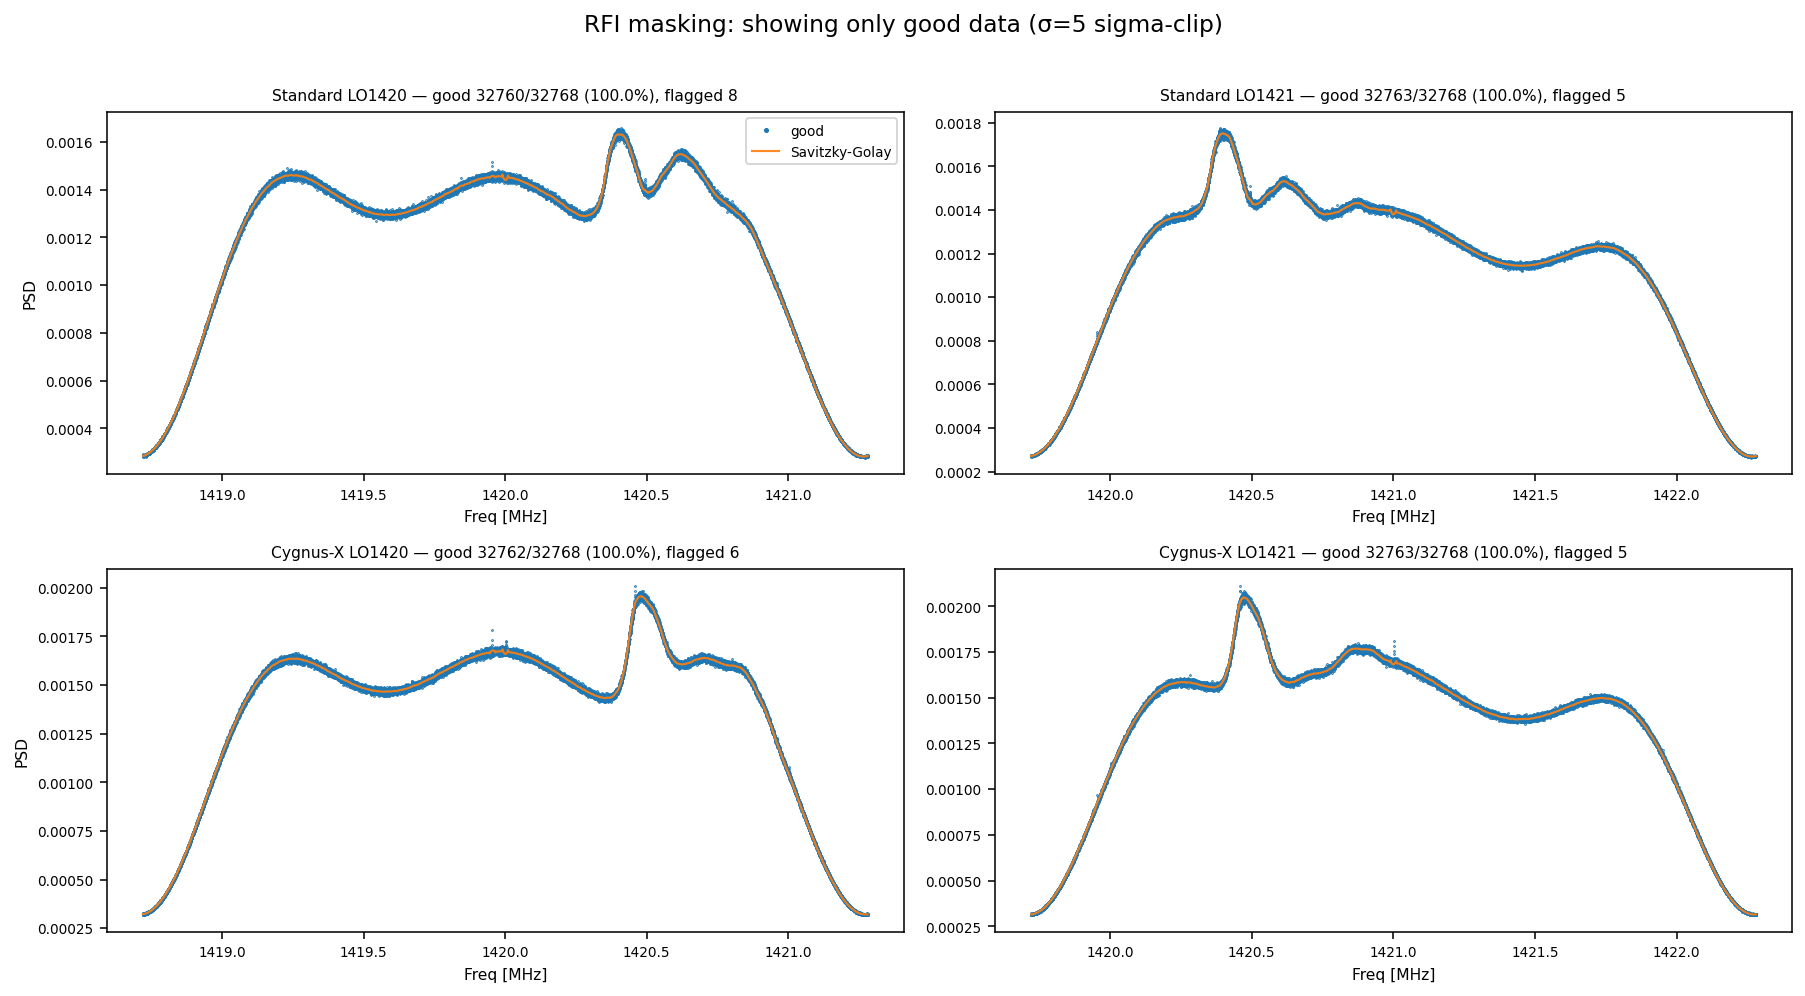

Good / flagged bins:
  Standard LO1420: good 32760 / 32768 (99.98%), flagged 8
  Standard LO1421: good 32763 / 32768 (99.98%), flagged 5
  Cygnus-X LO1420: good 32762 / 32768 (99.98%), flagged 6
  Cygnus-X LO1421: good 32763 / 32768 (99.98%), flagged 5


In [4]:
std_pair = load_lo_pair(DATA_ROOT / 'standard_combined_spectra')
cyg_pair = load_lo_pair(DATA_ROOT / 'cygnus-x_combined_spectra')

masks_std = {lo: sigma_clip_rfi_mask(std_pair[lo]) for lo in [1420, 1421]}
masks_cyg = {lo: sigma_clip_rfi_mask(cyg_pair[lo]) for lo in [1420, 1421]}

plot_rows = [
    ('Standard', std_pair, masks_std),
    ('Cygnus-X', cyg_pair, masks_cyg),
]
los = [1420, 1421]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

for row, (label, pair, masks) in enumerate(plot_rows):
    for col, lo in enumerate(los):
        spec = pair[lo]
        mask = masks[lo]
        freqs = spec.freqs / 1e6
        psd = spec.psd
        sm = spec.smooth(**SAVGOL)

        ax = axes[row, col]
        ax.plot(freqs[mask], psd[mask], '.', ms=0.8, color='C0', label='good')
        ax.plot(freqs, sm, lw=1.1, color='C1', alpha=0.9, label='Savitzky-Golay')

        n_good = int(np.sum(mask))
        n_flag = int(np.sum(~mask))
        ax.set_title(
            f'{label} LO{lo} — good {n_good}/{len(mask)} ({100*n_good/len(mask):.1f}%), '
            f'flagged {n_flag}',
            fontsize=8,
        )
        ax.set_xlabel('Freq [MHz]', fontsize=8)
        ax.set_ylabel('PSD' if col == 0 else '', fontsize=8)
        ax.tick_params(labelsize=7)
        if row == 0 and col == 0:
            ax.legend(fontsize=7, markerscale=4)

fig.suptitle(f'RFI masking: showing only good data (σ={RFI_SIGMA} sigma-clip)', y=1.01)
fig.tight_layout()
plt.show()

print('Good / flagged bins:')
for label, pair, masks in plot_rows:
    for lo in los:
        mask = masks[lo]
        n_good = int(np.sum(mask))
        n_flag = int(np.sum(~mask))
        print(f'  {label} LO{lo}: good {n_good} / {len(mask)} ({100*n_good/len(mask):.2f}%), '
              f'flagged {n_flag}')


## Cell 5 — PSD profile preparation

Build masked PSD and uncertainty arrays for each dataset/LO pair.

### Analysis role

These arrays are the canonical upstream products for ratio construction. Keeping both `psd`
and `std` after masking ensures uncertainty propagation remains consistent in all downstream
transforms and fits.

### Practical note

NaN-masked channels preserve index alignment across LO grids while preventing accidental use of
flagged bins in ratios, velocity transforms, and likelihood evaluations.



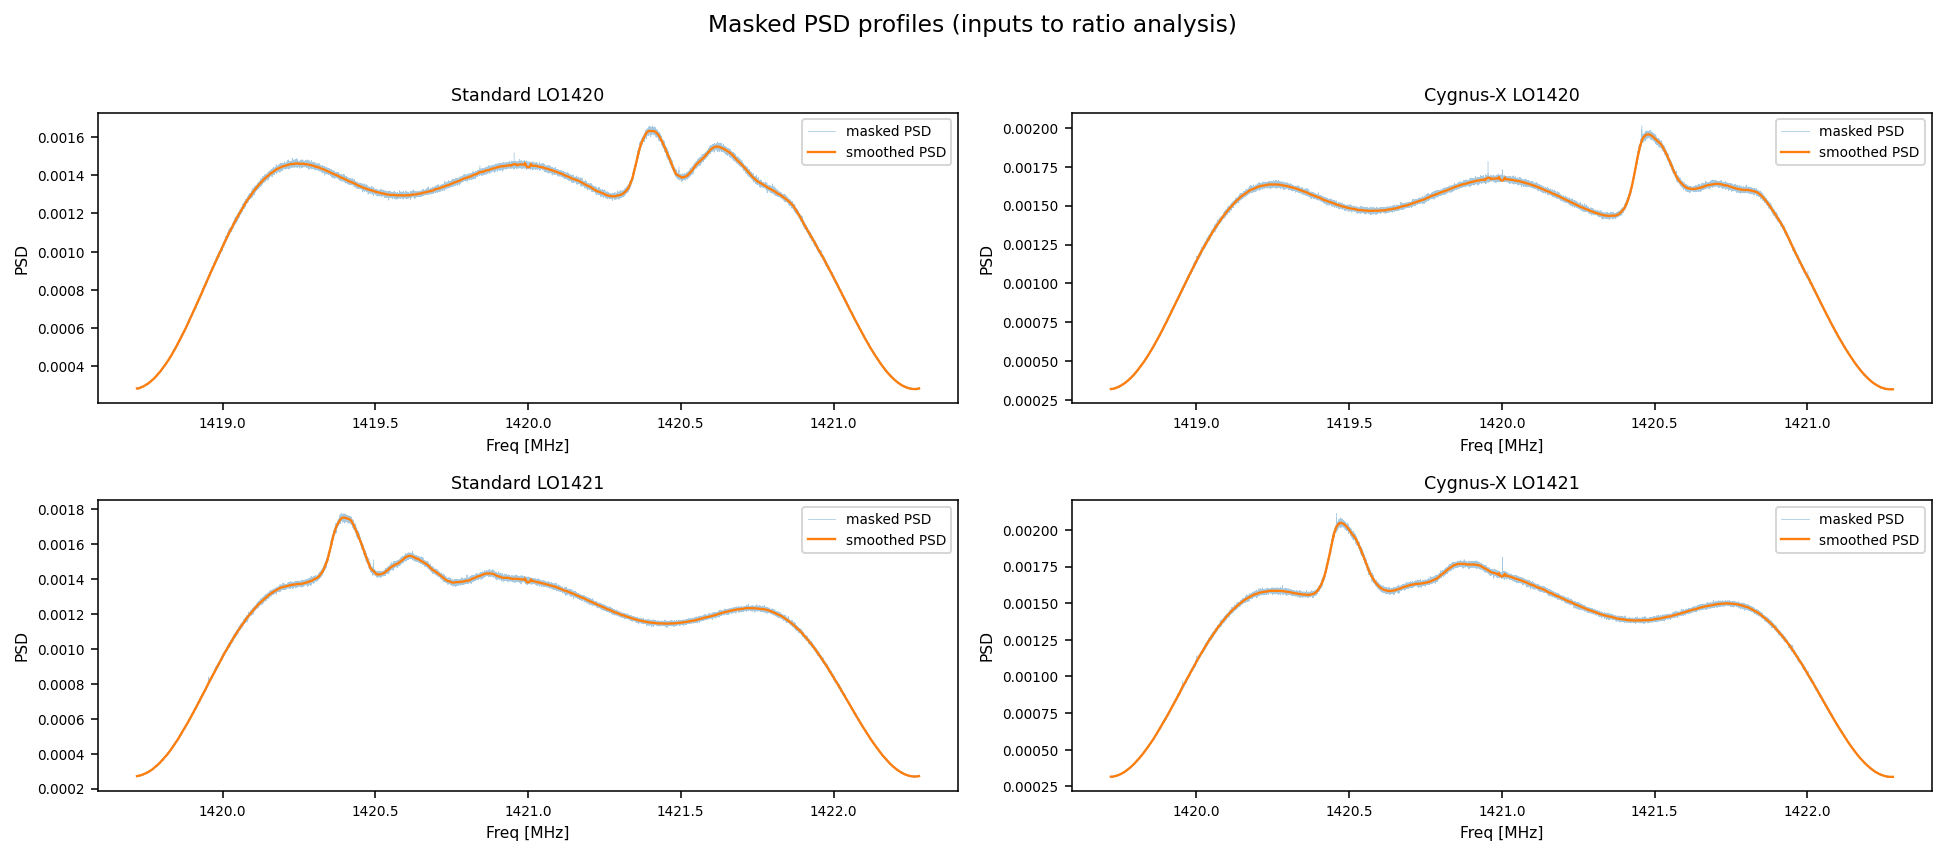

Mean / median PSD per spectrum (finite bins only):
  Standard LO1420: mean PSD = 0.001185  median = 0.001338
  Standard LO1421: mean PSD = 0.001130  median = 0.001220
  Cygnus-X LO1420: mean PSD = 0.001352  median = 0.001521
  Cygnus-X LO1421: mean PSD = 0.001335  median = 0.001473


In [5]:
# Build masked PSD profiles for all 4 spectra

def masked_psd_and_std(spectrum: Spectrum, mask: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    psd = np.array(spectrum.psd, float)
    std = np.array(spectrum.std, float)
    psd[~mask] = np.nan
    std[~mask] = np.nan
    return psd, std


psd_std = {}
psd_std_sigma = {}
psd_cyg = {}
psd_cyg_sigma = {}

for lo in [1420, 1421]:
    psd_std[lo], psd_std_sigma[lo] = masked_psd_and_std(std_pair[lo], masks_std[lo])
    psd_cyg[lo], psd_cyg_sigma[lo] = masked_psd_and_std(cyg_pair[lo], masks_cyg[lo])

fig, axes = plt.subplots(2, 2, figsize=(14, 6))

for col, (label, psd_dict, sigma_dict, pair) in enumerate([
    ('Standard', psd_std, psd_std_sigma, std_pair),
    ('Cygnus-X', psd_cyg, psd_cyg_sigma, cyg_pair),
]):
    for row, lo in enumerate([1420, 1421]):
        ax = axes[row, col]
        freqs_mhz = pair[lo].freqs / 1e6
        psd = psd_dict[lo]
        sm = pair[lo].smooth(**SAVGOL)

        ax.plot(freqs_mhz, psd, lw=0.4, alpha=0.4, color='C0', label='masked PSD')
        ax.plot(freqs_mhz, sm, lw=1.2, color='C1', label='smoothed PSD')
        ax.set_title(f'{label} LO{lo}', fontsize=9)
        ax.set_xlabel('Freq [MHz]', fontsize=8)
        ax.set_ylabel('PSD', fontsize=8)
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)

fig.suptitle('Masked PSD profiles (inputs to ratio analysis)', y=1.01)
fig.tight_layout()
plt.show()

print('Mean / median PSD per spectrum (finite bins only):')
for label, psd_dict in [('Standard', psd_std), ('Cygnus-X', psd_cyg)]:
    for lo in [1420, 1421]:
        p = psd_dict[lo]
        print(f'  {label} LO{lo}: mean PSD = {np.nanmean(p):.6f}  median = {np.nanmedian(p):.6f}')



## Cell 6 — Frequency-switched PSD ratio profiles

Construct

$$
R = \frac{P_{1420}}{P_{1421}},\qquad R^{-1}=\frac{P_{1421}}{P_{1420}},
$$

then analyze centered forms

$$
R-1,\qquad \frac{1}{R}-1.
$$

### Why centered ratio profiles

Centered ratios place line-free channels near zero, making baseline terms directly interpretable
and reducing degeneracy between additive baseline and Gaussian amplitudes.

### Velocity-frame treatment

- `R-1` is kept on the LO1420 frequency/velocity grid.
- `1/R-1` is kept on the LO1421 grid.
- Both are shifted to LSR using the same observation-time correction per dataset.

This preserves native sampling while enabling physically comparable velocity-domain fitting.



standard: LSR correction = -13.6737 km/s


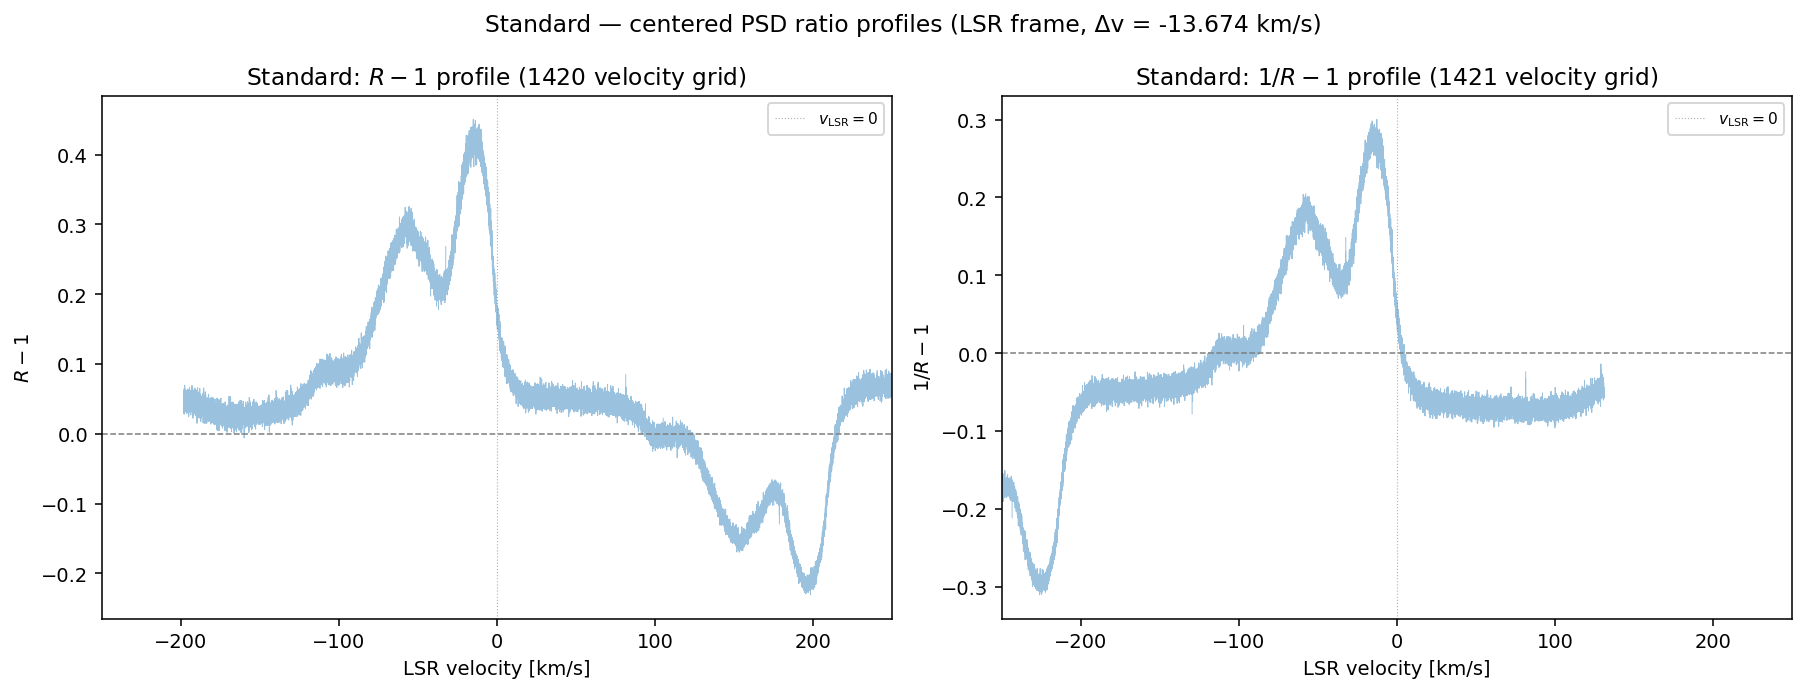

cygnus-x: LSR correction = -15.4179 km/s


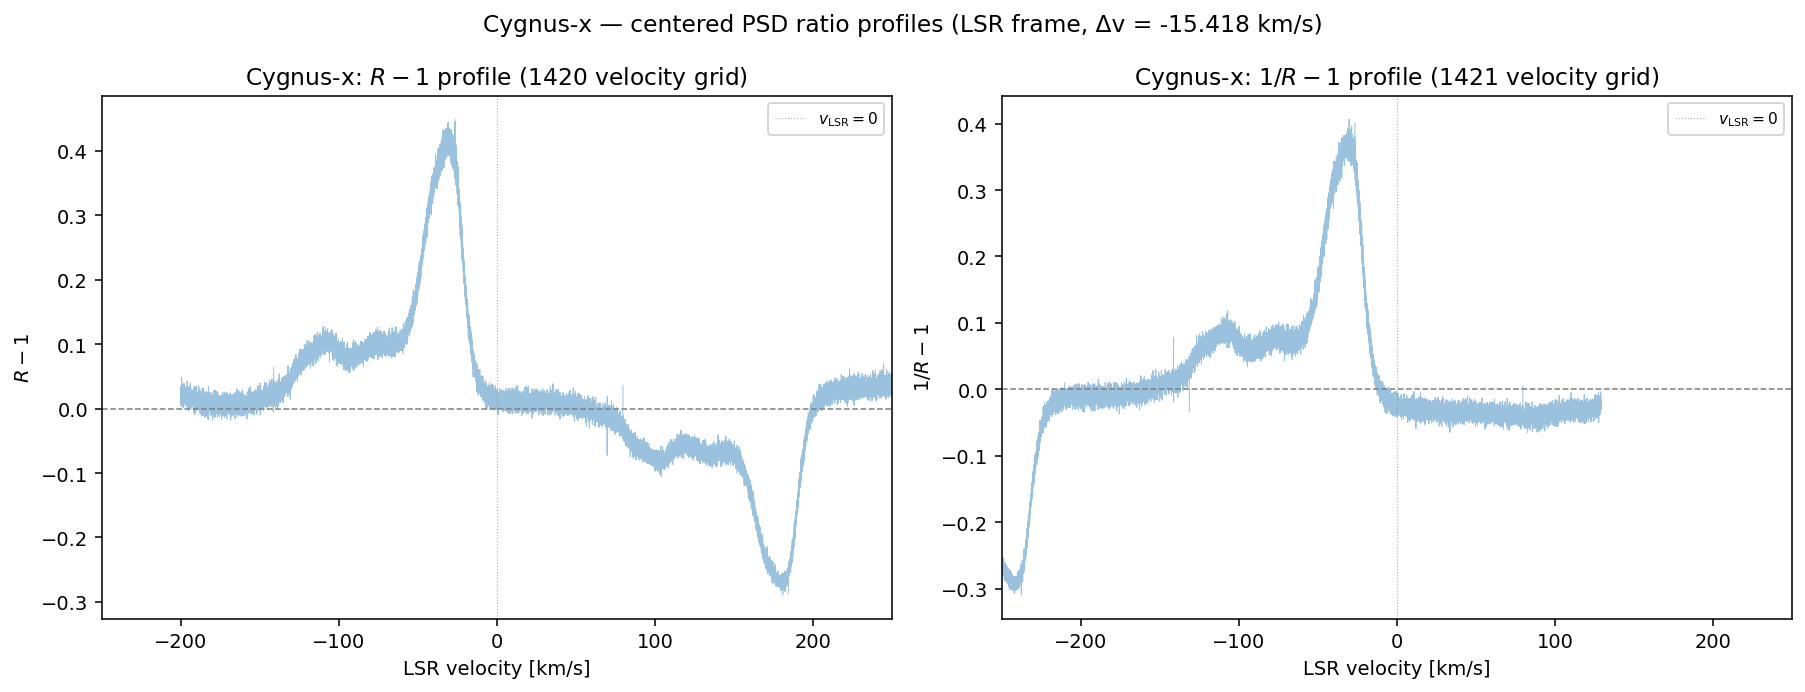

In [6]:
datasets = {
    'standard': {'pair': std_pair, 'masks': masks_std,
                 'psd': psd_std, 'psd_sigma': psd_std_sigma},
    'cygnus-x': {'pair': cyg_pair, 'masks': masks_cyg,
                 'psd': psd_cyg, 'psd_sigma': psd_cyg_sigma},
}

# Compute ratio profiles and LSR corrections per dataset
ratio_profiles = {}

for ds_name, ds in datasets.items():
    pair = ds['pair']
    masks = ds['masks']
    psd = ds['psd']
    psd_sig = ds['psd_sigma']

    # LSR correction (use LO1420 spectrum for timing)
    v_lsr = lsr_correction_kms(pair[1420])

    # Keep separate velocity axes: R on LO1420 grid, 1/R on LO1421 grid
    freqs_1420 = pair[1420].freqs
    freqs_1421 = pair[1421].freqs

    p0 = psd[1420].copy()
    p1 = psd[1421].copy()
    s0 = psd_sig[1420].copy()
    s1 = psd_sig[1421].copy()

    combined_bad = (~masks[1420] | ~masks[1421]
                    | ~np.isfinite(p0) | ~np.isfinite(p1)
                    | ~np.isfinite(s0) | ~np.isfinite(s1)
                    | (p0 <= 0) | (p1 <= 0))
    p0[combined_bad] = np.nan
    p1[combined_bad] = np.nan
    s0[combined_bad] = np.nan
    s1[combined_bad] = np.nan

    with np.errstate(divide='ignore', invalid='ignore'):
        R = p0 / p1
        R_inv = p1 / p0
        R_sigma = np.abs(R) * np.sqrt((s0 / p0) ** 2 + (s1 / p1) ** 2)
        R_inv_sigma = np.abs(R_inv) * np.sqrt((s1 / p1) ** 2 + (s0 / p0) ** 2)

    R_centered = R - 1.0
    Rinv_centered = R_inv - 1.0

    vel_lsr_1420 = velocity_axis(freqs_1420, HI_REST_FREQ_HZ) + v_lsr
    vel_lsr_1421 = velocity_axis(freqs_1421, HI_REST_FREQ_HZ) + v_lsr

    ratio_profiles[ds_name] = dict(
        freqs_1420=freqs_1420,
        freqs_1421=freqs_1421,
        R=R,
        R_sigma=R_sigma,
        R_inv=R_inv,
        R_inv_sigma=R_inv_sigma,
        R_centered=R_centered,
        Rinv_centered=Rinv_centered,
        vel_lsr_1420=vel_lsr_1420,
        vel_lsr_1421=vel_lsr_1421,
        v_lsr_correction=v_lsr,
    )

    print(f'{ds_name}: LSR correction = {v_lsr:+.4f} km/s')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for col, (vel, profile, ylabel, title) in enumerate([
        (vel_lsr_1420, R_centered, r'$R - 1$', r'$R-1$ profile (1420 velocity grid)'),
        (vel_lsr_1421, Rinv_centered, r'$1/R - 1$', r'$1/R-1$ profile (1421 velocity grid)'),
    ]):
        ax = axes[col]
        ax.plot(vel, profile, lw=0.5, alpha=0.45, color='C0')
        ax.axhline(0.0, color='gray', lw=0.8, ls='--')
        ax.axvline(0.0, color='gray', lw=0.6, ls=':', alpha=0.6,
                   label=r'$v_{\rm LSR}=0$')
        ax.set_xlabel('LSR velocity [km/s]')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{ds_name.capitalize()}: {title}')
        ax.set_xlim(-250, 250)
        ax.legend(fontsize=8)

    fig.suptitle(f'{ds_name.capitalize()} — centered PSD ratio profiles (LSR frame, '
                 f'Δv = {v_lsr:+.3f} km/s)')
    fig.tight_layout()
    plt.show()


## Cell 7 — Naive Gaussian + polynomial fit

Fit centered profiles with a robust deterministic model:

$$
y(v)=\sum_{k=1}^{N} A_k\exp\!\left[-\frac{(v-\mu_k)^2}{2\sigma_k^2}\right] + c_0 + c_1\,(v/100).
$$

### Windowing strategy

Fits are restricted to field-specific velocity windows to target the main HI feature while
limiting baseline-driven extrapolation:

| Field | Velocity window | Rationale |
|-------|----------------|-----------|
| standard ($\ell=120^\circ$) | $[-135,\,+20]$ km/s | captures expected outer-arm/forbidden-velocity structure at this longitude. |
| cygnus-x | $[-135,\,+30]$ km/s | includes local + Cygnus streaming structure without overextending baseline region. |

### Width bounds and physical motivation

Gaussian widths are constrained to

$$
\sigma\in[0.85,\,21.2]\,\mathrm{km\,s^{-1}}\quad\Leftrightarrow\quad\mathrm{FWHM}\in[2,\,50]~\mathrm{km\,s^{-1}}.
$$

- Lower bound suppresses residual-RFI-like spikes narrower than plausible CNM/WNM lines.
- Upper bound allows beam-blended components while discouraging non-physical ultra-broad fits
  that usually indicate baseline mismatch.

### Robustness choices

Multistart soft-L1 least squares and peak-based seeds reduce local-minimum dependence and improve
fit stability across datasets and ratio profiles.




Naive fit window for standard: [-135.0, +20.0] km/s


/var/folders/k_/sywjddzn17s8zyyk8mpk4nz80000gn/T/ipykernel_14457/2225856272.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


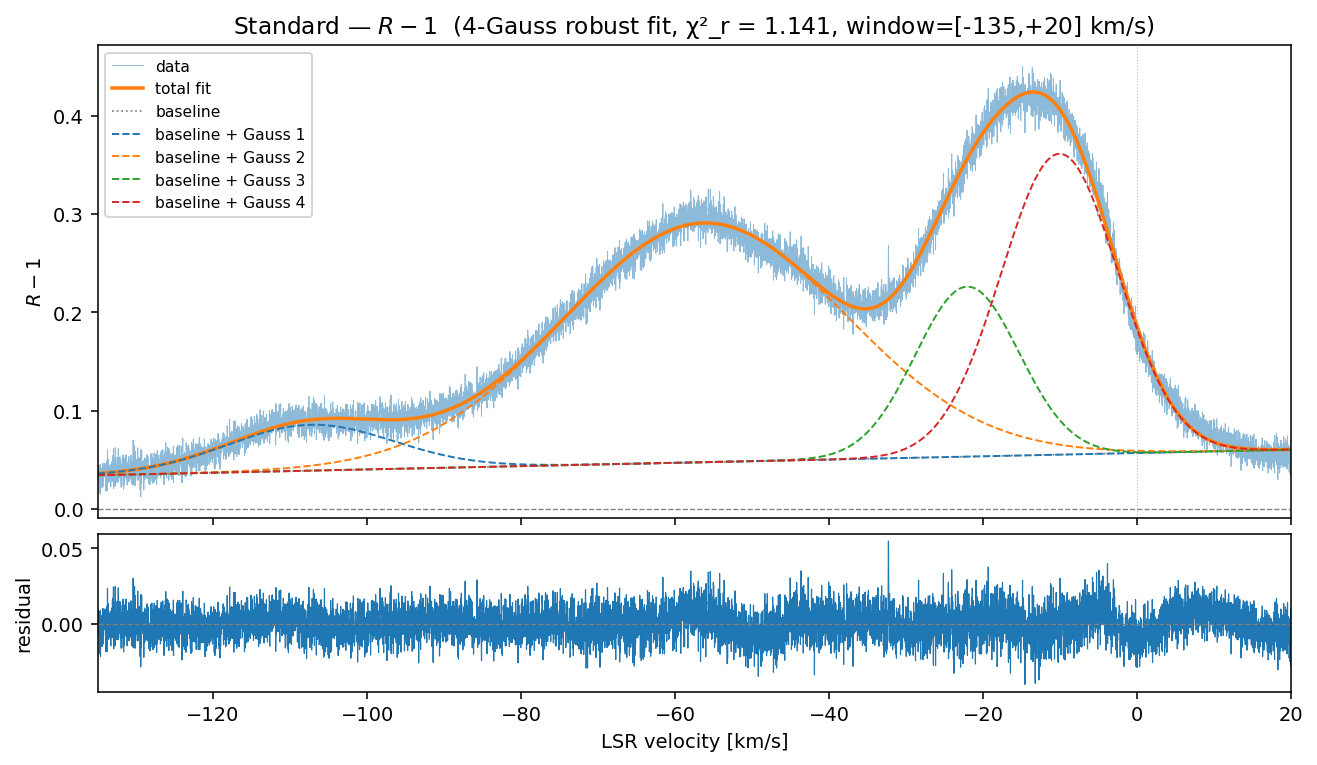

standard R  (χ²_r = 1.141):
  Comp 1: A=0.0467±0.0007  v0=-107.33±0.16 km/s  FWHM=25.30±0.54 km/s
  Comp 2: A=0.2437±0.0007  v0=-56.28±0.06 km/s  FWHM=43.16±0.18 km/s
  Comp 3: A=0.1730±0.0127  v0=-22.06±0.42 km/s  FWHM=15.84±0.40 km/s
  Comp 4: A=0.3063±0.0096  v0=-10.10±0.33 km/s  FWHM=17.82±0.31 km/s


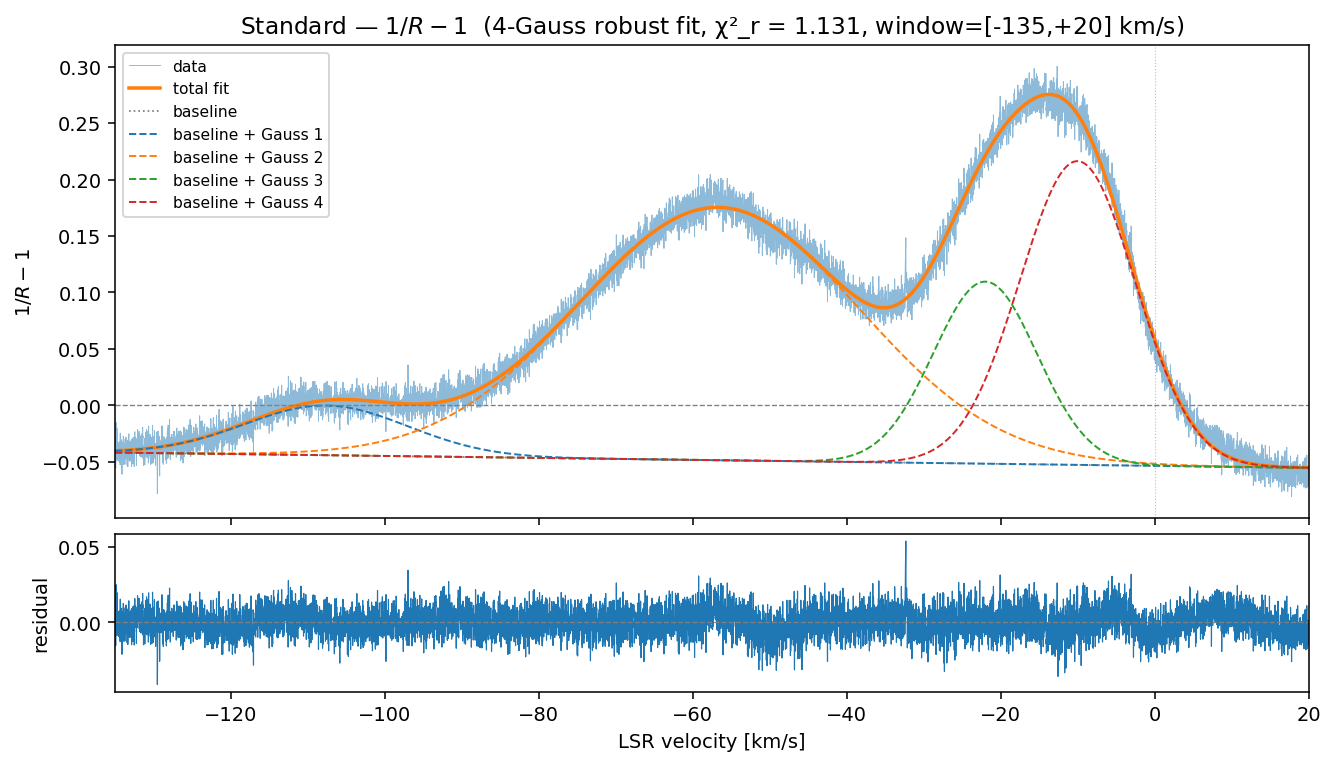

standard Rinv  (χ²_r = 1.131):
  Comp 1: A=0.0440±0.0007  v0=-107.57±0.15 km/s  FWHM=24.88±0.51 km/s
  Comp 2: A=0.2239±0.0006  v0=-56.64±0.05 km/s  FWHM=43.09±0.18 km/s
  Comp 3: A=0.1612±0.0109  v0=-21.97±0.40 km/s  FWHM=15.82±0.38 km/s
  Comp 4: A=0.2689±0.0085  v0=-10.00±0.32 km/s  FWHM=17.61±0.31 km/s

Naive fit window for cygnus-x: [-135.0, +30.0] km/s


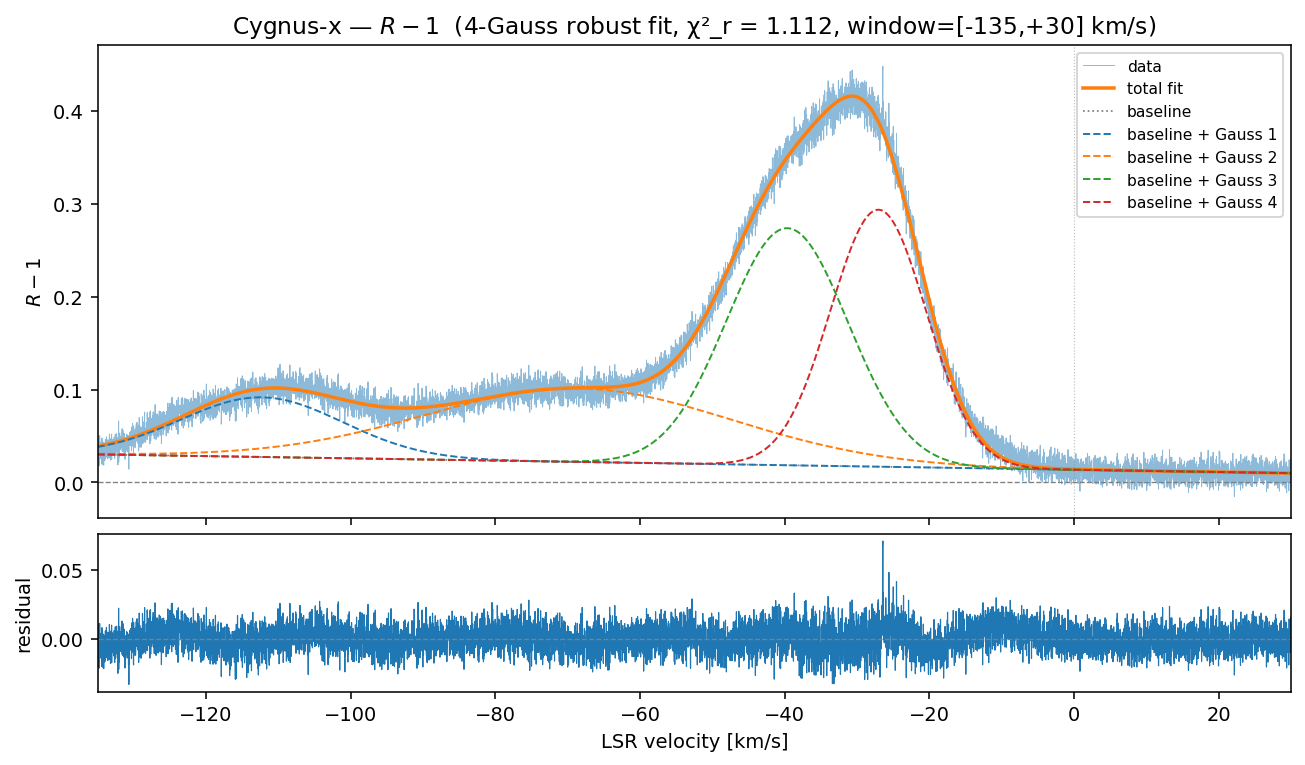

cygnus-x R  (χ²_r = 1.112):
  Comp 1: A=0.0643±0.0016  v0=-112.31±0.22 km/s  FWHM=26.32±0.58 km/s
  Comp 2: A=0.0792±0.0010  v0=-68.53±0.53 km/s  FWHM=49.93±1.94 km/s
  Comp 3: A=0.2554±0.0070  v0=-39.66±0.33 km/s  FWHM=19.79±0.45 km/s
  Comp 4: A=0.2768±0.0106  v0=-27.06±0.17 km/s  FWHM=15.59±0.16 km/s


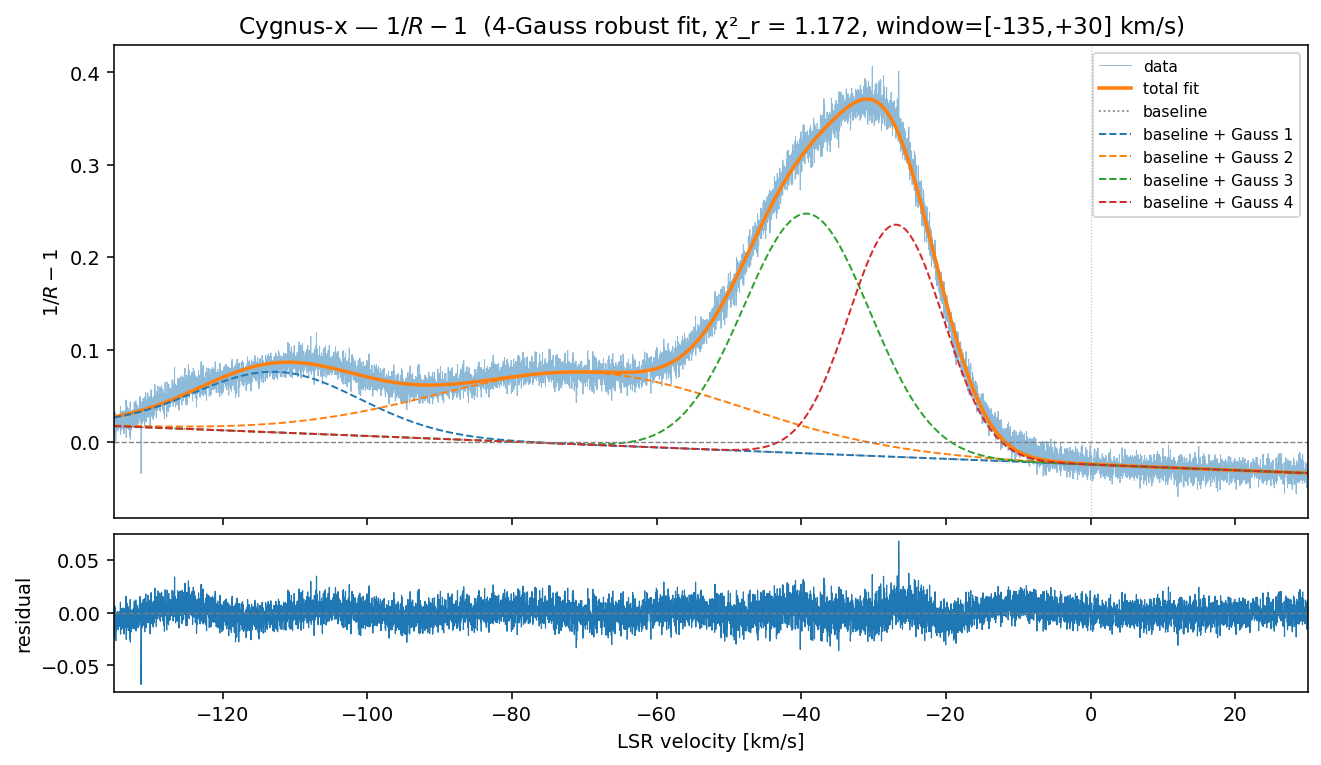

cygnus-x Rinv  (χ²_r = 1.172):
  Comp 1: A=0.0656±0.0018  v0=-112.44±0.24 km/s  FWHM=26.90±0.62 km/s
  Comp 2: A=0.0782±0.0011  v0=-69.43±0.53 km/s  FWHM=49.93±2.17 km/s
  Comp 3: A=0.2593±0.0075  v0=-39.22±0.36 km/s  FWHM=20.39±0.50 km/s
  Comp 4: A=0.2511±0.0120  v0=-26.88±0.17 km/s  FWHM=15.33±0.18 km/s


In [8]:
naive_fits = {}   # key: (ds_name, 'R' or 'Rinv')

for ds_name, rp in ratio_profiles.items():
    vel_min, vel_max = FIT_WINDOWS_KMS.get(ds_name, (FIT_VEL_MIN_KMS, FIT_VEL_MAX_KMS))
    print(f"\nNaive fit window for {ds_name}: [{vel_min:+.1f}, {vel_max:+.1f}] km/s")

    for profile_key, vel, profile, sigma_profile, label in [
        ('R', rp['vel_lsr_1420'], rp['R_centered'], rp['R_sigma'], r'$R-1$'),
        ('Rinv', rp['vel_lsr_1421'], rp['Rinv_centered'], rp['R_inv_sigma'], r'$1/R-1$'),
    ]:
        sigma_safe = np.where(np.isfinite(sigma_profile) & (sigma_profile > 0), sigma_profile, np.nan)

        try:
            fit = naive_gauss_poly_fit(
                vel,
                profile,
                sigma_safe,
                n_gauss=NAIVE_DEFAULT_N_GAUSS,
                poly_order=NAIVE_POLY_ORDER,
                vel_min=vel_min,
                vel_max=vel_max,
                random_seed=FIT_SEED,
            )
        except Exception as exc:
            print(f'  {ds_name} {profile_key}: naive fit failed — {exc}')
            continue

        naive_fits[(ds_name, profile_key)] = fit

        v_grid = np.linspace(vel_min, vel_max, 2000)
        model_curve = fit.model(v_grid)

        fig, axes = plt.subplots(
            2,
            1,
            figsize=(11, 6),
            gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05},
            sharex=True,
        )

        ax = axes[0]
        finite = np.isfinite(profile) & np.isfinite(sigma_safe) & (vel >= vel_min) & (vel <= vel_max)
        ax.plot(vel[finite], profile[finite], lw=0.5, alpha=0.5, color='C0', label='data')
        ax.plot(v_grid, model_curve, color='C1', lw=1.8, label='total fit')

        p = fit.popt
        baseline_grid = _eval_poly(v_grid, p[3 * fit.n_gauss:3 * fit.n_gauss + fit.poly_order + 1])
        ax.plot(v_grid, baseline_grid, color='gray', lw=0.9, ls=':', label='baseline')

        for k in range(fit.n_gauss):
            comp = p[3 * k] * np.exp(-0.5 * ((v_grid - p[3 * k + 1]) / p[3 * k + 2]) ** 2)
            ax.plot(v_grid, baseline_grid + comp, ls='--', lw=1.0, label=f'baseline + Gauss {k + 1}')

        ax.axhline(0.0, color='gray', lw=0.7, ls='--')
        ax.axvline(0, color='gray', lw=0.6, ls=':', alpha=0.5)
        ax.set_ylabel(label)
        ax.set_title(
            f'{ds_name.capitalize()} — {label}  '
            f'({fit.n_gauss}-Gauss robust fit, χ²_r = {fit.chi2_red:.3f}, '
            f'window=[{vel_min:+.0f},{vel_max:+.0f}] km/s)'
        )
        ax.set_xlim(vel_min, vel_max)
        ax.legend(fontsize=8)

        ax = axes[1]
        resid_fit = fit.data_fit - fit.model(fit.vel_fit)
        ax.plot(fit.vel_fit, resid_fit, lw=0.6, color='C0')
        ax.axhline(0, color='gray', lw=0.7, ls='--')
        ax.set_xlim(vel_min, vel_max)
        ax.set_xlabel('LSR velocity [km/s]')
        ax.set_ylabel('residual')

        fig.tight_layout()
        plt.show()

        print(f'{ds_name} {profile_key}  (χ²_r = {fit.chi2_red:.3f}):')
        for k in range(fit.n_gauss):
            A = fit.popt[3 * k]
            sA = fit.perr[3 * k]
            mu = fit.popt[3 * k + 1]
            smu = fit.perr[3 * k + 1]
            sig_k = fit.popt[3 * k + 2]
            ssig = fit.perr[3 * k + 2]
            fwhm = 2.355 * sig_k
            sfwhm = 2.355 * ssig
            print(
                f'  Comp {k+1}: A={A:.4f}±{sA:.4f}  '
                f'v0={mu:+.2f}±{smu:.2f} km/s  '
                f'FWHM={fwhm:.2f}±{sfwhm:.2f} km/s'
            )


## Cell 8 - Cross-check link to updated calibration product

This PSD-ratio analysis remains intentionally independent of absolute temperature scaling,
but we link to the updated calibration artifact for consistency checks:

- effective efficiency estimate from current data (`eta_eff_estimate.csv`).

This does not change the ratio-domain fit equations in this notebook; it only
constrains interpretation and uncertainty context in the report.

In [ ]:
import csv
from pathlib import Path


def _first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

eta_csv = _first_existing([
    Path('labs/02/report/eta_eff_estimate.csv'),
    Path('report/eta_eff_estimate.csv'),
    Path('../report/eta_eff_estimate.csv'),
])

if eta_csv is not None:
    with eta_csv.open() as f:
        row = next(csv.DictReader(f))
    print()
    print(f'Efficiency estimate file: {eta_csv}')
    print(f"  eta_eff           : {float(row['eta_eff']):.6f}")
    print(f"  eta_eff_sigma     : {float(row['eta_eff_sigma']):.6f}")
    print(f"  eta_eff_ci95      : [{float(row['eta_eff_ci95_lo']):.6f}, {float(row['eta_eff_ci95_hi']):.6f}]")
else:
    print('Efficiency estimate CSV not found in expected locations.')